In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
data = np.load(r'C:\Users\utente\astrostatistics_bicocca_2026\solutions\formationchannels.npy')

In [5]:
data

array([[17.12172682],
       [ 5.94121793],
       [ 6.35914124],
       ...,
       [34.34170191],
       [30.27018478],
       [25.93264098]], shape=(2950, 1))

In [8]:
print(data.shape)

(2950, 1)


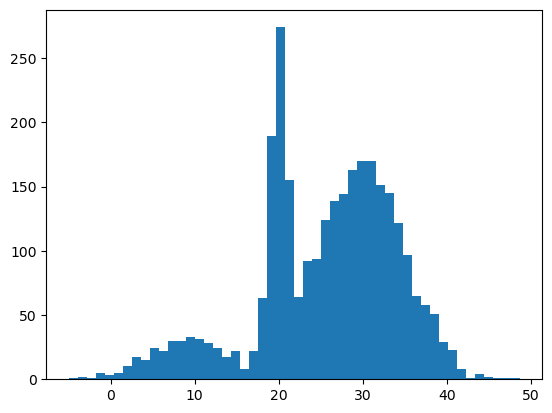

In [10]:
plt.hist(data, bins=50)
plt.show()

In [11]:
from sklearn.mixture import GaussianMixture

In [12]:
aic_val = []
models = []

for n in range(1, 11):
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(data)

    aic = gmm.aic(data)

    aic_val.append(aic)
    models.append(gmm)

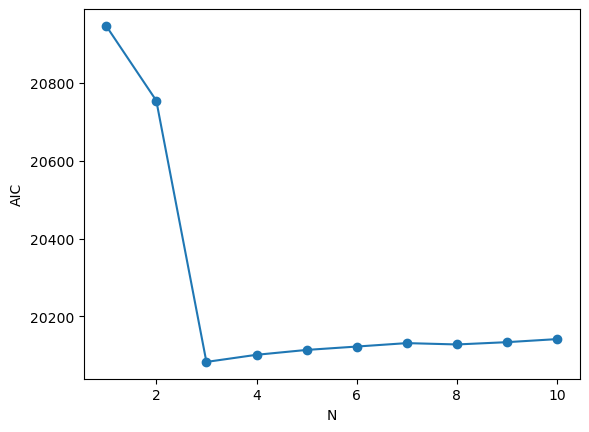

In [14]:
plt.plot(range(1,11), aic_val, marker='o')
plt.xlabel('N')
plt.ylabel('AIC')
plt.show()

In [15]:
best_N = np.argmin(aic_val)+1

In [16]:
best_model = models[best_N - 1]

In [17]:
print('Best N:', best_N)

Best N: 3


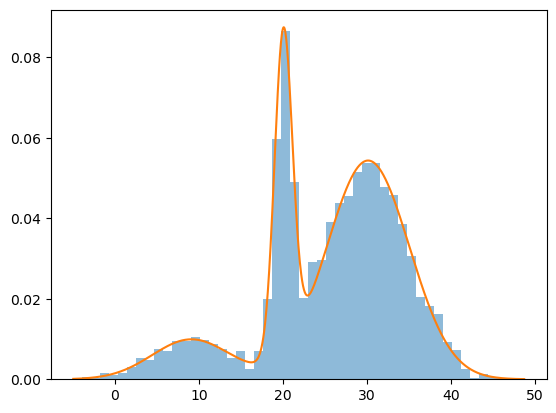

In [18]:
x = np.linspace(data.min(), data.max(), 1000)
logprob = best_model.score_samples(x.reshape(-1,1))
pdf = np.exp(logprob)

plt.hist(data, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf)
plt.show()

### Optional

In [19]:
probs = best_model.predict_proba(data)

In [20]:
print(probs.shape)

(2950, 3)


In [21]:
print(probs[0])

[0.28467927 0.32075757 0.39456317]


In [22]:
labels = np.argmax(probs, axis=1)

In [27]:
labels

array([2, 2, 2, ..., 0, 0, 0], shape=(2950,))